In [44]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [45]:
df = pd.read_csv('HousingData.csv')
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [46]:
df.isnull().sum()

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64

In [47]:
# df['RM'].fillna(df['RM'].mean() , inplace  =True )
# df.isnull().sum()
df.fillna(df.mean(), inplace=True)
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [48]:
x  = df.drop('MEDV',axis =1)
y =df['MEDV']

In [49]:
from sklearn.model_selection import  train_test_split  
x_train ,x_test ,y_train ,y_test = train_test_split(x,y)

In [50]:
from sklearn.preprocessing import MinMaxScaler 

scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_test =scaler.transform(x_test)

In [51]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(128,activation ='relu'))
model.add(Dense(1,activation='linear'))

#COMPILE 
model.compile(loss='mae' ,optimizer ='adam' ,metrics=['mse' ,'mae'])

In [52]:
model.fit(x_train ,y_train ,epochs=200)

Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 22.5730 - mae: 22.5730 - mse: 595.1293
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 21.9434 - mae: 21.9434 - mse: 568.1126
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 21.2080 - mae: 21.2080 - mse: 537.7023 
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 20.2889 - mae: 20.2889 - mse: 501.0651 
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 19.1607 - mae: 19.1607 - mse: 458.8189 
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 17.8049 - mae: 17.8049 - mse: 410.3233
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 16.2426 - mae: 16.2426 - mse: 358.6863  
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 14.5890 - mae: 14.5890 - mse: 307.0171 
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 12.9764 - mae: 12.9764 - mse: 257.0761 
Epoch 10/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 11.4861 - mae: 11.4861 - mse: 213.8120
Epoch 11/2

In [53]:
metrics = model.evaluate(x_test ,y_test)
metrics

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 2.9575 - mae: 2.9575 - mse: 23.5174 


[2.9575138092041016, 23.517431259155273, 2.9575138092041016]

In [54]:
y_pred = model.predict(x_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


In [55]:
y_test =np.array(y_test).reshape(-1,1)


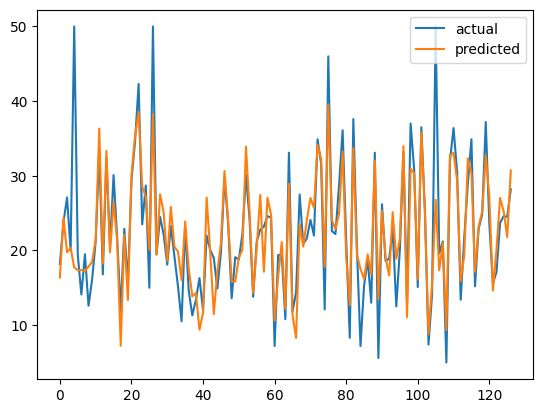

In [56]:
plt.plot(y_test ,label="actual")
plt.plot(y_pred ,label="predicted")
plt.legend()